FileNotFoundError: [Errno 2] No such file or directory: 'C:\\mnt\\data\\stability_polar_plot.png'

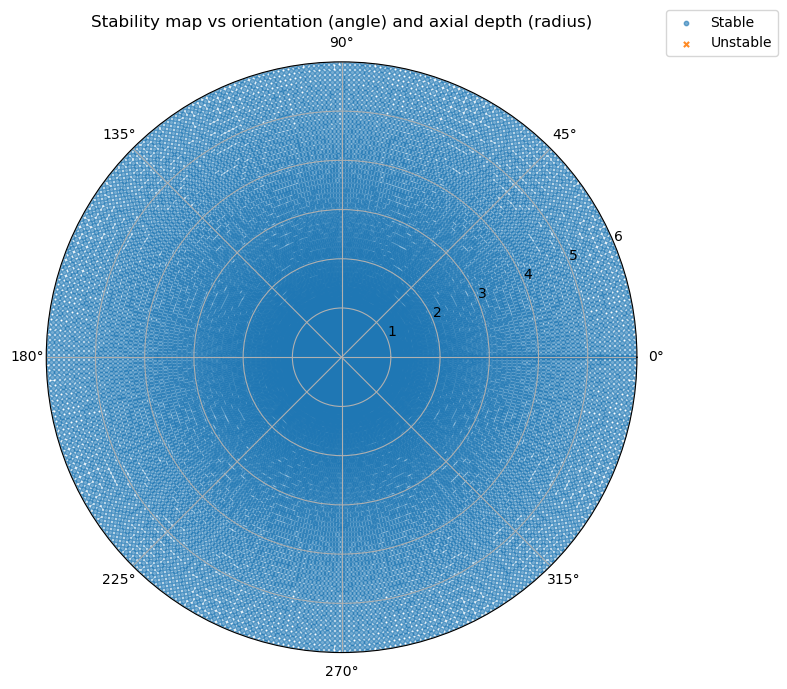

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- Functions from user's code (minimal subset needed) ---
def rotation_theta_z(theta):
    c, s = np.cos(theta), np.sin(theta)
    return np.array([[c, -s],
                     [s,  c]])

def compute_entry_exit_angles_downmilling(r_engagement: float, v: float, D: float):
    R = D/2
    b = r_engagement
    v = 0.0  # full entry assumption
    arg = np.clip((R - b) / R , -1.0, 1.0)
    arg1 = np.clip(v / (D/2) ,0.0, 1.0)
    phi_st = np.pi / 2 + np.arcsin(arg)
    phi_ex = np.pi / 2 + np.arccos(arg1)  # = pi when v=0
    return phi_st , phi_ex

def zero_order_dF(c: float, a_axial: float, b_radial: float, D: float, N_teeth: float,
                  phi_st: float, phi_ex: float, Ktc: float, Krc: float):
    v = 0.0  # full entry assumption
    dphi_st_db = -1.0 / np.sqrt(b_radial*(D-b_radial))
    dphi_ex_dv = -2.0 / np.sqrt(D**2 - 4*v**2)

    def q(phi):
        h = c*np.sin(phi)
        T = np.array([[-np.cos(phi), -np.sin(phi)],
                      [ np.sin(phi), -np.cos(phi)]])
        K = np.array([Ktc, Krc])
        return a_axial * (T @ K) * h

    dF_dv = N_teeth/(2*np.pi) * q(phi_ex) * dphi_ex_dv
    dF_db = N_teeth/(2*np.pi) * (-q(phi_st) * dphi_st_db)

    dv_dx, dv_dy = -1.0, 0.0
    db_dx, db_dy =  0.0, -1.0

    dF_dx = dF_dv*dv_dx + dF_db*db_dx
    dF_dy = dF_dv*dv_dy + dF_db*db_dy

    return np.column_stack((dF_dx, dF_dy))

def state_matrix(M, C, K_eff):
    Z = np.zeros((2, 2))
    I = np.eye(2)
    Minv = np.linalg.inv(M)
    return np.block([
        [Z,                 I],
        [-Minv @ K_eff, -Minv @ C]
    ])

def max_real_eig(M, C, K, Kp0, theta):
    R = rotation_theta_z(theta)
    Kp = R @ Kp0 @ R.T
    K_eff = K - Kp
    A = state_matrix(M, C, K_eff)
    eigvals = np.linalg.eigvals(A)
    return np.max(np.real(eigvals))

# --- Demo-friendly: if you run this in your environment, replace these with your loaded M2,C2,K2 ---
# Here we create placeholder matrices so the plot code runs in this notebook.
# IMPORTANT: Replace with your real matrices from load_macro_from_npz(...)
M2 = np.array([[1.0, 0.0],
               [0.0, 1.2]])
C2 = np.array([[0.08, 0.01],
               [0.01, 0.09]])
K2 = np.array([[2.2e4, 1.5e3],
               [1.5e3, 1.8e4]])

# Cutting params (from your script)
Ktc = 1930.4
Krc = 1159.6

c_feed = 0.15
b_radial = 5.0
D = 20.0
N_teeth = 4

phi_st, phi_ex = compute_entry_exit_angles_downmilling(r_engagement=b_radial, v=0.0, D=D)

# Sweep setup
theta_deg = np.arange(0, 361, 1)
thetas = np.deg2rad(theta_deg)

a_max = 6.0          # mm (adjust as needed)
n_a = 61             # 0..a_max inclusive
a_vals = np.linspace(0.0, a_max, n_a)

# Build polar scatter points
TH, AAX = np.meshgrid(thetas, a_vals, indexing="xy")  # shape (n_a, n_theta)
TH_flat = TH.ravel()
A_flat = AAX.ravel()

stable_mask = np.empty_like(A_flat, dtype=bool)

# Evaluate stability on the grid
for i, (th, aax) in enumerate(zip(TH_flat, A_flat)):
    Kp0 = zero_order_dF(
        c=c_feed, a_axial=aax, b_radial=b_radial, D=D, N_teeth=N_teeth,
        phi_st=phi_st, phi_ex=phi_ex, Ktc=Ktc, Krc=Krc
    )
    stable_mask[i] = (max_real_eig(M2, C2, K2, Kp0, th) < 0.0)

# Plot
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection="polar")

# Use different markers (not explicit colors) to denote stable vs unstable
ax.scatter(TH_flat[stable_mask], A_flat[stable_mask], s=10, marker="o", alpha=0.6, label="Stable")
ax.scatter(TH_flat[~stable_mask], A_flat[~stable_mask], s=14, marker="x", alpha=0.9, label="Unstable")

ax.set_title("Stability map vs orientation (angle) and axial depth (radius)")
ax.set_rlabel_position(22.5)
ax.set_theta_zero_location("E")
ax.set_theta_direction(1)  # CCW
ax.set_rlim(0, a_max)
ax.legend(loc="upper right", bbox_to_anchor=(1.25, 1.1))

out_path = "/mnt/data/stability_polar_plot.png"
plt.tight_layout()


plt.savefig(out_path, dpi=200)
out_path


In [ ]:

def alpha_matrix(phi_st, phi_ex, Kr):
    def F(phi):
        return np.array([
            [0.5*(np.cos(2*phi) - 2*Kr*phi + Kr*np.sin(2*phi)),
             0.5*(-np.sin(2*phi) - 2*phi + Kr*np.cos(2*phi))],
            [0.5*(-np.sin(2*phi) + 2*phi + Kr*np.cos(2*phi)),
             0.5*(-np.cos(2*phi) - 2*Kr*phi - Kr*np.sin(2*phi))]
        ])
    return F(phi_ex) - F(phi_st)

def A0_matrix(N_teeth, phi_st, phi_ex, Ktc, Krc):
    Kr = Krc / Ktc
    alpha = alpha_matrix(phi_st, phi_ex, Kr)
    A0 = (N_teeth/(2*np.pi)) * alpha
    return A0, alpha

A0, alpha = A0_matrix(N_teeth, phi_st, phi_ex, Ktc, Krc)
print("A0=\n", A0)

def compute_entry_exit_angles_downmilling(
    
    r_engagement : float,
    v : float,
    D : float
    
):
    
    # Current tool entry / exit angles: --> https://www.sciencedirect.com/science/article/pii/S0888327020307044#b0160
    # Downmilling setup
    R = D/2
    b =  r_engagement  # radial depth of cut 
    v =  0.0  # We assume full entry of the tool thus distance from the edge is zero. (No partial entry)
    arg = np.clip((R - b) / R , -1.0, 1.0) # np.clip(1.0 - 2.0*b/D, -1.0, 1.0)
    arg1 = np.clip(v / (D/2) ,0.0, 1.0)
    phi_st = np.pi / 2 + np.arcsin(arg)
    phi_ex = np.pi / 2 + np.arccos(arg1)
        
    return phi_st , phi_ex


M2 = np.array([[1.0, 0.0],
               [0.0, 1.2]])
C2 = np.array([[0.08, 0.01],
               [0.01, 0.09]])
K2 = np.array([[2.2e4, 1.5e3],
               [1.5e3, 1.8e4]])

# Cutting params (from your script)
Ktc = 1930.4
Krc = 1159.6

c_feed = 0.15
b_radial = 5.0
D = 20.0
N_teeth = 4



